<a href="https://colab.research.google.com/github/anjaperovic22/credit-card-fraud-detection/blob/main/Credit_Card_Fraud_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Primena neuronskih mreža za predvidjanje prevara u finansijama (credit card fraud)


## Neophodni importi

In [ ]:
# 1. Osnovne biblioteke
import io
import numpy as np
import pandas as pd
import random
import os

# 2. PyTorch biblioteke za duboko učenje
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.neural_network import MLPClassifier

# 3. Scikit-Learn za preprocesiranje i evaluaciju
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score

# 4. Vizuelizacija
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
RAND_STATE = 42

## Učitavanje skupa podataka

In [ ]:
from google.colab import files
data_file = files.upload()

Saving creditcard.csv to creditcard (1).csv


In [ ]:
print(data_file.keys())

dict_keys(['creditcard (1).csv'])


In [ ]:
df = pd.read_csv(io.BytesIO(data_file['creditcard (1).csv']))

In [ ]:
print("Prvih 5 redova u skupu podataka: \n")
df.head()

Prvih 5 redova u skupu podataka: 



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
print("Osnovne informacije o skupu podataka: \n")
df.info()

Osnovne informacije o skupu podataka: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     

<p align="justify">
Detaljnija analiza skupa podataka nalazi se u dokumentaciji projekta. Nakon učitavanja dataseta i inicijalnog pregleda, vidimo da se u njemu nalazi 30 numeričkih kolona koje se koriste za klasifikaciju transakcija na regularne i prevare. Kolone od V1 do V28 su prethodno skalirane korišćenjem PCA transformacije. Promenljiva Amount je ostala u svom izvornom obliku i predstavlja iznos izvršene transakcije, dok promenljiva Time predstavlja broj sekundi proteklih od prve transakcije u skupu. Ciljna promenljiva Class je binarna i označava da li je transakcija prevara (1) ili ne (0). Nakon podele na trening i test skup, moraćemo da skaliramo Amount i Time kako bi svi ulazi bili u istom opsegu.
</p>

## Podela na train i test skupove

In [ ]:
#Definisanje ulaznih varijabli (X) - izbacujemo ciljnu kolonu Class
X = df.drop(columns=['Class'])

# Definisanje ciljne varijable (y) - uzimamo samo kolonu Class
y = df['Class']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RAND_STATE, stratify=y
)

## Skaliranje podataka

In [ ]:
scaler = StandardScaler()

kolone_za_skaliranje = ['Time', 'Amount']

X_train_scaled = X_train.copy()
X_train_scaled[kolone_za_skaliranje] = scaler.fit_transform(X_train[kolone_za_skaliranje])
X_test_scaled = X_test.copy()
X_test_scaled[kolone_za_skaliranje] = scaler.transform(X_test[kolone_za_skaliranje])

# **Model 1: Baseline model (skicit-learn MLPClassifier)**

<p align="justify">U dubokom učenju, višeslojni perceptron (MLP) je vrsta moderne <i>feedforward</i> neuronske mreže koja se sastoji od potpuno povezanih neurona sa nelinearnim aktivacionim funkcijama, organizovanih u slojeve. Poznat je po tome što može da razlikuje podatke koji nisu linearno razdvojivi.</p>

## Pravljenje modela

In [ ]:
model_1_sklearn_mlp = MLPClassifier(
    hidden_layer_sizes=(64,32),
    max_iter=1000,
    random_state=RAND_STATE
)

In [ ]:
print("Arhitektura mreže:")
print("Broj ulaznih neurona:", X_train.shape[1])
print("Skriveni slojevi:", model_1_sklearn_mlp.hidden_layer_sizes)

Arhitektura mreže:
Broj ulaznih neurona: 30
Skriveni slojevi: (64, 32)


<p align="justify"> Model se sastoji od ulaznog sloja sa 30 neurona (što odgovara broju prediktorskih atributa), dva skrivena sloja i jednog izlaznog neurona. Prvi skriveni sloj sadrži 64 neurona, što vidimo iz dimenzija prve matrice težina (30 x 64) i odgovarajućeg bias vektora. Drugi skriveni sloj dodatno sažima informacije na 32 neurona (matrica težina 64 x 32). Mreža se završava jednim izlaznim neuronom (matrica 32 x 1), što je standardna konfiguracija za probleme binarne klasifikacije gde model na izlazu treba da generiše jednu vrednost (verovatnoću pripadnosti klasi prevare). </p>

## Trening modela

In [ ]:
model_1_sklearn_mlp.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)

## Promena vrednosti funkcije greške tokom treninga

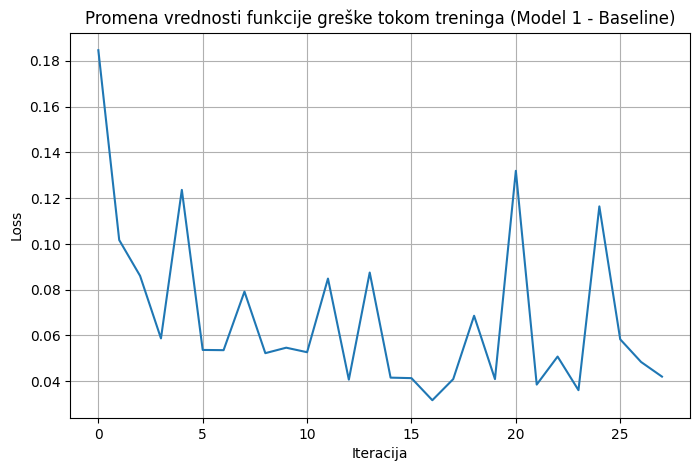

In [ ]:
# Prikazati promenu vrednosti funkcije greške (loss) tokom treninga
plt.figure(figsize=(8,5))
plt.plot(model_1_sklearn_mlp.loss_curve_)
plt.xlabel("Iteracija")
plt.ylabel("Loss")
plt.title("Promena vrednosti funkcije greške tokom treninga (Model 1 - Baseline)")
plt.grid()
plt.show()

<p align="justify">
Na osnovu prikazanog grafika promene vrednosti funkcije greške tokom treninga, uočava se izrazita nestabilnost i prisustvo velikih oscilacija iz epohe u epohu. U stabilnim uslovima obučavanja, kriva greške bi trebalo da ima linearan ili gladak eksponencijalni pad, dok ovde vidimo nagle skokove vrednosti (npr. oko 4, 13, 20. i 24. iteracije).
</p>

<p align="justify">
Ovakvo ponašanje MLPClassifier modela direktno je uzrokovano specifičnostima našeg skupa podataka i ograničenjima podrazumevanih algoritama optimizacije:
</p>


*    <p align="justify"><b>Ekstremni debalans klasa</b>: Tokom stohastičkog ili mini-batch gradijentnog spusta, algoritam deli podatke u manje pakete. S obzirom na to da prevare čine manje od 1% skupa, model u većini paketa vidi samo regularne transakcije i uspešno minimizuje grešku. Međutim, kada model naiđe na paket koji sadrži nekoliko prevara, on pravi drastičnu grešku u predikciji jer te primere retko viđa. To dovodi do naglog ažuriranja težina i skoka celokupne funkcije greške u toj iteraciji.</p>
*    <p align="justify"><b>Suboptimalna stopa učenja</b>: Visoka fiksna stopa učenja uzrokuje da model previše agresivno menja svoje parametre nakon svake greške. Umesto da lagano konvergira ka globalnom minimumu, model "preskače" optimalne vrednosti težina i luta kroz prostor performansi.</p>

In [ ]:
print("\nBroj izlaznih neurona:", model_1_sklearn_mlp.n_outputs_)

for i, coef in enumerate(model_1_sklearn_mlp.coefs_):
    print(f"Matrica težina {i+1}: {coef.shape}")

for i, bias in enumerate(model_1_sklearn_mlp.intercepts_):
    print(f"Bias vektor {i+1}: {bias.shape}")

print("\nBroj iteracija:", model_1_sklearn_mlp.n_iter_)
print("Finalni loss:", model_1_sklearn_mlp.loss_)


Broj izlaznih neurona: 1
Matrica težina 1: (30, 64)
Matrica težina 2: (64, 32)
Matrica težina 3: (32, 1)
Bias vektor 1: (64,)
Bias vektor 2: (32,)
Bias vektor 3: (1,)

Broj iteracija: 28
Finalni loss: 0.042041395872980496


<p align="justify">Proces obučavanja je automatski zaustavljen nakon tačno 28 iteracija, što ukazuje na to da je algoritam aktivirao <i><b>early stopping</b></i> pravilo usled stabilizacije funkcije greške. Iako finalna vrednost loss-a iznosi relativno niskih 0.042, ovaj podatak moramo uzeti sa rezervom. Zbog ekstremnog debalansa klasa, niska vrednost funkcije greške može biti posledica izuzetno visoke tačnosti nad većinskom klasom (regularne transakcije), dok stvarna uspešnost prepoznavanja prevara mora biti evaluirana kroz specifične metrike poput Recall-a i Precision-a.</p>

## Kreiranje predikcija

In [ ]:
y_pred_1 = model_1_sklearn_mlp.predict(X_test)
y_proba_1 = model_1_sklearn_mlp.predict_proba(X_test)

## Evaluacija modela

### Matrica konfuzije

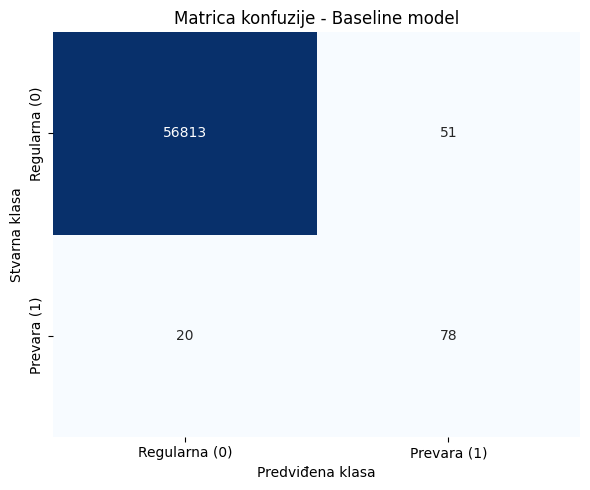

In [ ]:
cm = confusion_matrix(y_test, y_pred_1)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Regularna (0)', 'Prevara (1)'],
            yticklabels=['Regularna (0)', 'Prevara (1)'])

plt.title("Matrica konfuzije - Baseline model")
plt.xlabel("Predviđena klasa")
plt.ylabel("Stvarna klasa")

plt.tight_layout()
plt.show()

<p align="justify">Model je uspešno identifikovao 78 stvarnih prevara (<b>True Positive</b>) i tačno klasifikovao 56.813 regularnih transakcija (<b>True Negative</b>). S obzirom na to da je ovo inicijalni model pokrenut bez naprednih tehnika balansiranja, sposobnost mreže da locira većinu prevara predstavlja solidnu polaznu osnovu.</p>

<p align="justify">Pored solidnog starta, model pokazuje dva ključna nedostatka. Prvi je prisustvo 20 lažno negativnih rezultata (<b>False Negative</b>) – to su stvarne prevare koje je model propustio i označio kao bezopasne, što u realnom bankarskom sistemu generiše direktne finansijske gubitke. Drugi nedostatak je 51 lažno pozitivna predikcija (<b>False Positive</b>), odnosno situacije u kojima su regularni korisnici greškom blokirani, što narušava korisničko iskustvo.</p>

### Klasifikacioni izveštaj

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
print("Klasifikacioni izveštaj za Baseline Model:\n")
print(classification_report(y_test, y_pred_1, target_names=['Regularna (0)', 'Prevara (1)']))

Klasifikacioni izveštaj za Baseline Model:

               precision    recall  f1-score   support

Regularna (0)       1.00      1.00      1.00     56864
  Prevara (1)       0.60      0.80      0.69        98

     accuracy                           1.00     56962
    macro avg       0.80      0.90      0.84     56962
 weighted avg       1.00      1.00      1.00     56962



<p align="justify"> Ukupna nominalna tačnost modela (<b>Accuracy</b>) iznosi maksimalnih 1.00. Međutim, ova vrednost je visoka isključivo zbog ekstremnog prisustva većinske klase (56.864 uzoraka). Ovo je odličan primer zašto je ukupna tačnost potpuno nepouzdana i varljiva metrika za evaluaciju modela u uslovima visokog debalansa podataka. </p>

<p align="justify">Fokusiranjem na manjinsku klasu (98 uzoraka), uočavamo da model ostvaruje odziv (<b>Recall</b>) od 0.80, što znači da uspešno detektuje 80% stvarnih prevara. Sa druge strane, preciznost (<b>Precision</b>) iznosi 0.60, što ukazuje na to da su 40% transakcija koje je model označio kao sumnjive zapravo bile regularne.</p>

<p align="justify">Harmonijska sredina ovih performansi izražena je kroz <b>F1-score</b> koji za klasu prevara iznosi 0.69. Ovaj broj predstavlja zvaničnu ocenu našeg trenutnog modela i služi kao polazna tačka. Glavni cilj u nastavku projekta biće optimizacija mreže kroz PyTorch okruženje kako bi se ovaj F1-score značajno unapredio.</p>

## Osiguravanje ponovljivosti eksperimenata

<p align="justify">Kako bi se osigurala potpuna ponovljivost (<i>reproducibility</i>) eksperimenata i omogućilo dosledno praćenje performansi, implementirano je fiksiranje semena generatora pseudo-slučajnih brojeva (<i>random seed</i>). S obzirom na stohastičku prirodu procesa obučavanja neuronskih mreža u PyTorch radnom okviru – koja obuhvata nasumičnu inicijalizaciju težinskih koeficijenata, mešanje podataka u mini-grupama i primenu tehnika regularizacije – model je pri svakom novom pokretanju koda davao blago drugačije rezultate. Postavljanjem fiksnog semena garantuje se determinističko izvršavanje procesa. Na ovaj način se osigurava da su sve zabeležene promene u vrednostima funkcije greške i metrikama evaluacije isključivo posledica modifikacija arhitekture modela ili podešavanja hiperparametara, a ne slučajnih varijacija sistema.</p>

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# **Model 2: Baseline PyTorch model**

<p align="justify">Prelazak na PyTorch donosi ključne fundamentalne razlike koje direktno utiču na uspešnost rešavanja problema detekcije prevara:

<p align="justify">U <i>scikit-learn</i> modelu podaci su procesirani u obliku standardnih NumPy nizova. PyTorch, sa druge strane, koristi <b>tenzore</b> – višedimenzionalne matrične strukture podataka. Tenzori su matematički optimizovani za rad u dubokom učenju iz dva razloga:</p>
<p align="justify">
<b>GPU akceleracija:</b> Za razliku od NumPy nizova koji su striktno vezani za procesor, PyTorch tenzori se mogu jednim komandnim pozivom prebaciti na grafičku kartu (GPU). Ovo omogućava masovnu paralelizaciju i dramatično ubrzava milione matričnih množenja koja se dešavaju tokom obučavanja naše mreže koja sadrži ogroman broj transakcija.</p>

<p align="justify">
<b>Dinamički grafovi i Autograd:</b> PyTorch tenzori u sebi nose ugrađen mehanizam za automatsko računanje izvoda (gradijenata) – `autograd`. Tokom prolaza napred (<b>forward pass</b>), PyTorch automatski konstruiše dinamički računarski graf koji pamti sve operacije nad tenzorima, što omogućava trenutno i matematički precizno propagiranje greške unazad (<b>backpropagation</b>).</p>

<p align="justify">Kroz Python kod u PyTorch-u dobijamo veću kontrolu nad mrežom. Možemo ručno da definišemo tačan protok tenzora kroz slojeve, eksperimentišemo sa različitim metodama inicijalizacije težina i ubacujemo napredne slojeve za regularizaciju direktno između linearnih transformacija.</p>

## Konverzija podataka u tenzore

<p align="justify">
Pre definisanja arhitekture i samog procesa obučavanja modela dubokog učenja (Modeli 2, 3 i 4), neophodno je bilo transformisati originalne podatke iz standardnog tabelarnog formata.</p>
<p align="justify">
Transformisani tenzori obeležja i pripadajućih oznaka pakuju se u TensorDataset objekte. Ovaj korak kreira čvrstu apstrakciju koja osigurava da svaka pojedinačna transakcija ostane bezbedno i neraskidivo vezana za svoju klasu (regularna ili prevara) tokom celokupnog toka obučavanja.</p>

In [ ]:
# 1. Pretvaranje podataka u PyTorch tenzore
X_train_2 = torch.tensor(X_train_scaled.values, dtype=torch.float32)
X_test_2 = torch.tensor(X_test_scaled.values, dtype=torch.float32)
y_train_2 = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
y_test_2 = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

# 2. Smeštanje tenzora u dataset objekte
train_dataset = TensorDataset(X_train_2, y_train_2)
test_dataset = TensorDataset(X_test_2, y_test_2)

# 3. Uvođenje paketa i konfiguracija DataLoader-a
BATCH_SIZE = 1024
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

<p align="justify">
Za trening skup eksplicitno je aktivirano nasumično mešanje podataka (shuffle=True), čime se sprečava da mreža memoriše redosled unosa i osigurava neophodna stohastičnost pri optimizaciji gradijentnog spusta. Nasuprot tome, mešanje testnog skupa je isključeno (shuffle=False), što je kritičan uslov za očuvanje konzistentnosti redosleda prilikom finalne evaluacije i generisanja klasifikacionog izveštaja.</p>

## Pravljenje modela

<p align="justify">
U ovom koraku namerno konstruišemo klasu <code>FraudDetectionMLP</code> sa potpuno identičnom arhitekturom kakvu je imao i naš bazični <i>scikit-learn</i> model. Mreža se sastoji od ulaznog sloja (30 atributa), prvog skrivenog sloja sa 64 neurona, drugog skrivenog sloja sa 32 neurona i konačnog izlaznog sloja sa jednim neuronom.
</p>

<p align="justify">
Zadržavanje identične topologije i aktivacionih funkcija (ReLU) je ključna inženjerska odluka iz razloga <b>izolacije eksperimenta</b>. Da bismo sprovele validnu komparativnu analizu i dokazale prednosti PyTorch okruženja (a kasnije i uvođenja težinskih koeficijenata), neophodno je da svi ostali hiperparametri i strukturni elementi ostanu konstantni (tzv. <i>baseline-to-baseline</i> poređenje). Na taj način eliminišemo mogućnost da je promena u performansama nastala usled variranja kompleksnosti same mreže.
</p>

In [ ]:
class FraudDetectionMLP(nn.Module):
    def __init__(self):
        super(FraudDetectionMLP, self).__init__()

        self.fc1 = nn.Linear(30, 64) # Prvi skriveni sloj, uči prve nelinearne komb. ulaznih varijabli
        self.relu1 = nn.ReLU() # Primenjujemo nelinearnu aktivacionu funkciju

        self.fc2 = nn.Linear(64, 32) # Drugi skriveni sloj, uzima apstraktne karakteristike izvučene u prvom sloju i dodatno ih sažima
        self.relu2 = nn.ReLU() # Primenjujemo opet aktivacionu funkciju

        self.fc3 = nn.Linear(32, 1) # Konačni izlazni sloj

    def forward(self, x): # Definisanje protoka podataka
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.fc3(x)
        return x

set_seed(RAND_STATE)

model_2_pytorch_base = FraudDetectionMLP()
print(model_2_pytorch_base)

FraudDetectionMLP(
  (fc1): Linear(in_features=30, out_features=64, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=32, out_features=1, bias=True)
)


## Trening modela

<p align="justify">
Za razliku od biblioteke <i>scikit-learn</i> koja automatizuje proces obučavanja, PyTorch zahtijeva eksplicitnu implementaciju trening petlje kroz epohe i minipakete (engl. <i>mini-batches</i>). Ovaj pristup pruža potpunu kontrolu nad algoritmom propagacije greške unazad i ažuriranjem težinskih koeficijenata.
</p><p align="justify">Model je obučavan korišćenjem optimizatora <b>Adam</b> sa stopom učenja 0.001 i funkcijom gubitka <b>BCEWithLogitsLoss</b>, koja je standardna za binarnu klasifikaciju.</p>
<p align="justify">
Obučavanje se izvršava kroz <b>20 epoha</b>. Unutar svake epohe, podaci se procesiraju u paketima od po 1024 uzoraka preko `train_loader`-a, gde se nad svakim paketom ručno izvršava standardni matematički ciklus dubokog učenja.
</p>


In [ ]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model_2_pytorch_base.parameters(), lr=0.001)

pytorch_loss_history = []

EPOCHS = 20

for epoch in range(EPOCHS):
    model_2_pytorch_base.train()
    tekuci_loss_za_epohu = 0.0
    broj_paketa = 0

    for batch_X, batch_y in train_loader:
        # Resetujemo gradijente od prethodnog koraka
        optimizer.zero_grad()
        # 1. Prolaz napred (Forward pass)
        outputs = model_2_pytorch_base(batch_X)
        # 2. Računanje greške
        loss = criterion(outputs, batch_y)
        # 3. Prolaz unazad (Backward pass - računanje gradijenata)
        loss.backward()
        # 4. Ažuriranje težina (Optimization step)
        optimizer.step()

        tekuci_loss_za_epohu += loss.item()
        broj_paketa += 1

    # Računamo prosečan loss za celu epohu
    prosecan_loss_epohe = tekuci_loss_za_epohu / broj_paketa
    pytorch_loss_history.append(prosecan_loss_epohe)

    print(f"Epoha [{epoch+1}/{EPOCHS}] - Prosečan Loss: {prosecan_loss_epohe:.5f}")

Epoha [1/20] - Prosečan Loss: 0.08874
Epoha [2/20] - Prosečan Loss: 0.00518
Epoha [3/20] - Prosečan Loss: 0.00411
Epoha [4/20] - Prosečan Loss: 0.00366
Epoha [5/20] - Prosečan Loss: 0.00328
Epoha [6/20] - Prosečan Loss: 0.00286
Epoha [7/20] - Prosečan Loss: 0.00258
Epoha [8/20] - Prosečan Loss: 0.00244
Epoha [9/20] - Prosečan Loss: 0.00233
Epoha [10/20] - Prosečan Loss: 0.00222
Epoha [11/20] - Prosečan Loss: 0.00212
Epoha [12/20] - Prosečan Loss: 0.00207
Epoha [13/20] - Prosečan Loss: 0.00200
Epoha [14/20] - Prosečan Loss: 0.00194
Epoha [15/20] - Prosečan Loss: 0.00189
Epoha [16/20] - Prosečan Loss: 0.00185
Epoha [17/20] - Prosečan Loss: 0.00181
Epoha [18/20] - Prosečan Loss: 0.00174
Epoha [19/20] - Prosečan Loss: 0.00175
Epoha [20/20] - Prosečan Loss: 0.00171


## Promena vrednosti funkcije greške tokom treninga

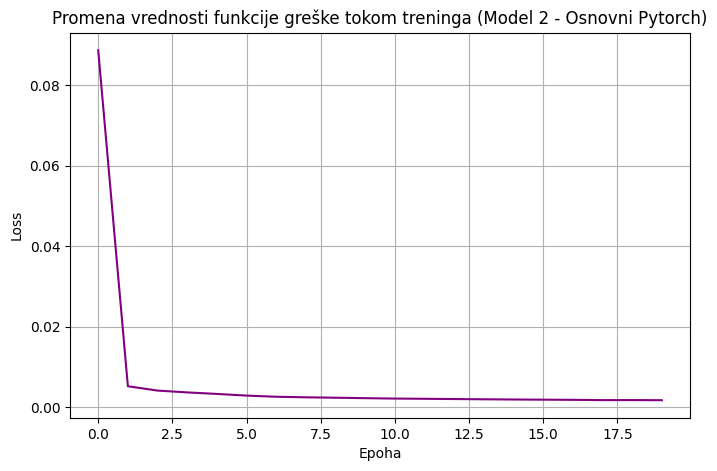

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(pytorch_loss_history, color='purple')
plt.xlabel("Epoha")
plt.ylabel("Loss")
plt.title("Promena vrednosti funkcije greške tokom treninga (Model 2 - Osnovni Pytorch)")
plt.grid()
plt.show()

<p align="justify">Vrednosti gubitka tokom epoha prikazane su na grafikonu iznad. Gubitak je konstantno opadao od početnih 0.08 do 0.0017 u 20. epohi, što ukazuje da je model uspešno naučio obrasce u podacima. Odsustvo naglih skokova i monotoni pad sugerišu stabilnu konvergenciju. Nema znakova preteranog prilagođavanja (overfitting) na samom trening skupu, ali je neophodno proveriti i performanse na test skupu.</p>

## Evaluacija

In [ ]:
model_2_pytorch_base.eval()
y_pred_2 = []
y_true_2 = []

with torch.no_grad():
    for batch_X_2, batch_y_2 in test_loader:
        outputs = model_2_pytorch_base(batch_X_2)
        # Primenjujemo sigmoid funkciju
        verovatnoce = torch.sigmoid(outputs)
        # Prag odlučivanja je 0.5: sve preko toga je 1 (Prevara), ostalo je 0
        batch_pred_2 = (verovatnoce >= 0.5).float()
        y_pred_2.extend(batch_pred_2.cpu().numpy().flatten())
        y_true_2.extend(batch_y_2.cpu().numpy().flatten())

Nakon završenog procesa obučavanja, pokrenut je postupak evaluacije modela nad testnim skupom podataka kroz sledeće faze:

<p align="justify"><b>1. Prebacivanje modela u režim evaluacije</b>: Model smo eksplicitno prebacili u režim rada za testiranje. Ovo privremeno deaktivira specifične trening slojeve, obezbeđujući konzistentnost predikcija.</p>
<p align="justify"><b>2. Isključivanje računanja gradijenata</b>: Pošto se nad testnim podacima ne vrši obučavanje niti ažuriranje težina, ovaj blok sprečava PyTorch da gradi računarski graf i pamti gradijente. Time se drastično smanjuje potrošnja memorije i ubrzava izvršavanje koda.</p>

<p align="justify"><b>3. Konverzija izlaza u binarne klase (Sigmoid + Threshold)</b>: Budući da model u poslednjem sloju generiše sirove vrednosti (engl. <i>logits</i>), funkcija <code>torch.sigmoid(outputs)</code> kompresuje izlaze u opseg [0, 1], transformišući ih u stvarne verovatnoće prevare.</p>

   * <p align="justify">Primenom praga odlučivanja od 0.5, sve transakcije sa većom verovatnoćom automatski dobijaju klasu 1 (Prevara), dok ostale dobijaju klasu 0 (Regularna transakcija).</p>

<p align="justify">Konačni rezultati se ravnaju i prebacuju iz PyTorch tenzora u standardne NumPy nizove radi dalje metričke evaluacije.</p>

### Matrica konfuzije

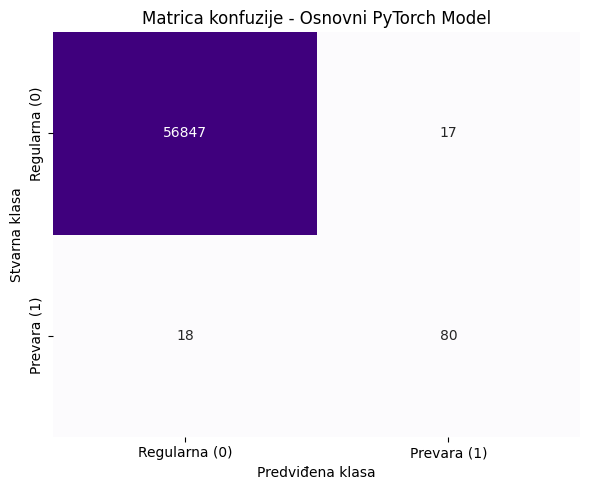

In [ ]:
cm_pytorch = confusion_matrix(y_true_2, y_pred_2)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_pytorch, annot=True, fmt='g', cmap='Purples', cbar=False,
            xticklabels=['Regularna (0)', 'Prevara (1)'],
            yticklabels=['Regularna (0)', 'Prevara (1)'])

plt.title("Matrica konfuzije - Osnovni PyTorch Model")
plt.xlabel("Predviđena klasa")
plt.ylabel("Stvarna klasa")
plt.tight_layout()
plt.show()

<p align="justify">
Inicijalni PyTorch model uspešno je identifikovao 80 stvarnih prevara (<b>True Positive</b>) i tačno klasifikovao 56.847 regularne transakcije (<b>True Negative</b>). Činjenica da je mreža već u svom osnovnom obliku, bez dodatnog otežavanja klasa, uspela da locira ~80% anomalija pokazuje da prelazak na dinamičko PyTorch okruženje i Adam optimizator daje izuzetno agresivnu granicu odlučivanja.
</p>

<p align="justify">
Sa svega 17 lažnih uzbuna (<b>False Positive</b>) i 18 propuštenih prevara (<b> False Negative</b>) vidljivo je značajno poboljšanje u odnosu na <i>skicit-learn</i> model.
</p>

### Klasifikacioni izveštaj

In [ ]:
print("Klasifikacioni izveštaj za osnovni PyTorch model \n")
print(classification_report(y_true_2, y_pred_2, target_names=['Regularna (0)', 'Prevara (1)']))

Klasifikacioni izveštaj za osnovni PyTorch model 

               precision    recall  f1-score   support

Regularna (0)       1.00      1.00      1.00     56864
  Prevara (1)       0.82      0.82      0.82        98

     accuracy                           1.00     56962
    macro avg       0.91      0.91      0.91     56962
 weighted avg       1.00      1.00      1.00     56962



<p align="justify">
Nominalna ukupna tačnost modela (<b>Accuracy</b>) iznosi visokih 1.00 (100%).
</p>

<p align="justify">
Za klasu prevara (1), koja je ključna za poslovanje, model ostvaruje:

*   **Preciznost** = 0.82 – od svih transakcija koje je model označio kao sumnjive, 82% su zaista prevare, što znači da je samo 18% lažnih uzbuna.

*   **Odziv** = 0.82 – model uspešno detektuje 82% svih stvarnih prevara, što je solidan nivo osetljivosti.

*   **F1-score** = 0.82 – harmonijska sredina preciznosti i odziva potvrđuje dobru izbalansiranost ove dve metrike.

**Makro prosek** (macro avg) od 0.91 za preciznost, odziv i F1 pokazuje da model podjednako dobro radi na obe klase, uprkos debalansu.
</p>

<p align="justify">
Osnovni PyTorch model predstavlja značajan napredak u odnosu na inicijalni scikit-learn model. Sa F1-score-om od 0.82 za klasu prevara, ovaj model nudi solidnu osnovu za dalje finom podešavanje. Niska stopa lažnih uzbuna (preciznost 0.82) čini ga pogodnim za realnu primenu, dok bi se daljim povećanjem težine klase prevara mogao dodatno poboljšati odziv, uz potencijalni blagi pad preciznosti.
</p>

# **Model 3: Težinski PyTorch MLP model**

## Pravljenje modela

<p align="justify">
Kako smo zaključile nakon evaluacije prva dva modela, bazične mreže imaju tendenciju da ignorišu manjinsku klasu (Prevara) jer minimizuju ukupnu grešku fokusirajući se na većinsku klasu. Da bismo rešile ovaj problem bez veštačkog generisanja novih uzoraka (kao što je SMOTE tehnika), primenjujemo metodu <b>penalizacije funkcije greške u realnom vremenu</b>.
</p>

In [ ]:
broj_regularnih = (y_train == 0).sum()
broj_prevara = (y_train == 1).sum()

# Težina se računa kao odnos: broj_negativnih / broj_pozitivnih
klasna_tezina = broj_regularnih / broj_prevara

print(f"Broj regularnih transakcija u treningu: {broj_regularnih}")
print(f"Broj prevara u treningu: {broj_prevara}")
print(f"Izračunata težina za klasu prevara (pos_weight): {klasna_tezina:.2f}")

# Pretvaramo u PyTorch tenzor da bismo je prosledile funkciji greške
pos_weight_tensor = torch.tensor([klasna_tezina], dtype=torch.float32)

Broj regularnih transakcija u treningu: 227451
Broj prevara u treningu: 394
Izračunata težina za klasu prevara (pos_weight): 577.29


<p align="justify">
U ovom segmentu koda eksplicitno računamo odnos između broja regularnih transakcija i broja prevara unutar trening skupa podataka. Dobijeni koeficijent (<code>klasna_tezina</code>) predstavlja matematički multiplikator koji govori funkciji greške koliko puta jače treba da "kazni" model za svaku promašenu prevaru u poređenju sa promašenom regularnom transakcijom.
</p>

## Trening modela

<p align="justify">
Proces obučavanja trećeg modela zadržava istu strukturu kroz epohe i minipakete kao i prethodni PyTorch model, ali sa jednom kritičnom izmenom u samoj matematičkoj definiciji optimizacije.
</p>

<p align="justify">
Ključna modifikacija u ovoj fazi jeste konfiguracija funkcije gubitka: standardnoj <b>BCEWithLogitsLoss</b> funkciji eksplicitno prosleđujemo prethodno izračunati <code>pos_weight_tensor</code>. Za razliku od bazičnog modela gde je svaka greška vrednovana isto, ova otežana funkcija gubitka sada primorava optimizator <b>Adam</b> (sa nepromenjenom stopom učenja 0.001) da višestruko strože kažnjava model kada god propusti prevaru (lažno negativan ishod).
</p>

In [ ]:
set_seed(RAND_STATE)

model_3_pytorch_weighted = FraudDetectionMLP()

# IZMENA: Prosleđujemo pos_weight funkciji greške
criterion_weighted = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
optimizer_weighted = optim.Adam(model_3_pytorch_weighted.parameters(), lr=0.001)

# Lista za praćenje novog loss-a
weighted_loss_history = []
EPOCHS = 20

print("Započinjemo obučavanje Modela 3 (Težinski PyTorch MLP)...\n")

for epoch in range(EPOCHS):
    model_3_pytorch_weighted.train()
    tekuci_loss_za_epohu = 0.0
    broj_paketa = 0

    for batch_X, batch_y in train_loader:
        optimizer_weighted.zero_grad()

        # Forward pass
        outputs = model_3_pytorch_weighted(batch_X)

        # Računanje otežane greške
        loss = criterion_weighted(outputs, batch_y)

        # Backward pass i optimizacija
        loss.backward()
        optimizer_weighted.step()

        tekuci_loss_za_epohu += loss.item()
        broj_paketa += 1

    prosecan_loss_epohe = tekuci_loss_za_epohu / broj_paketa
    weighted_loss_history.append(prosecan_loss_epohe)

    print(f"Epoha [{epoch+1}/{EPOCHS}] - Prosečan Težinski Loss: {prosecan_loss_epohe:.5f}")

Započinjemo obučavanje Modela 3 (Težinski PyTorch MLP)...

Epoha [1/20] - Prosečan Težinski Loss: 0.52104
Epoha [2/20] - Prosečan Težinski Loss: 0.26077
Epoha [3/20] - Prosečan Težinski Loss: 0.21571
Epoha [4/20] - Prosečan Težinski Loss: 0.20397
Epoha [5/20] - Prosečan Težinski Loss: 0.19070
Epoha [6/20] - Prosečan Težinski Loss: 0.16547
Epoha [7/20] - Prosečan Težinski Loss: 0.14876
Epoha [8/20] - Prosečan Težinski Loss: 0.14269
Epoha [9/20] - Prosečan Težinski Loss: 0.12927
Epoha [10/20] - Prosečan Težinski Loss: 0.11961
Epoha [11/20] - Prosečan Težinski Loss: 0.11186
Epoha [12/20] - Prosečan Težinski Loss: 0.10734
Epoha [13/20] - Prosečan Težinski Loss: 0.09436
Epoha [14/20] - Prosečan Težinski Loss: 0.08710
Epoha [15/20] - Prosečan Težinski Loss: 0.08289
Epoha [16/20] - Prosečan Težinski Loss: 0.07605
Epoha [17/20] - Prosečan Težinski Loss: 0.07608
Epoha [18/20] - Prosečan Težinski Loss: 0.06944
Epoha [19/20] - Prosečan Težinski Loss: 0.07191
Epoha [20/20] - Prosečan Težinski Loss

## Promena vrednosti funkcije greške tokom treninga

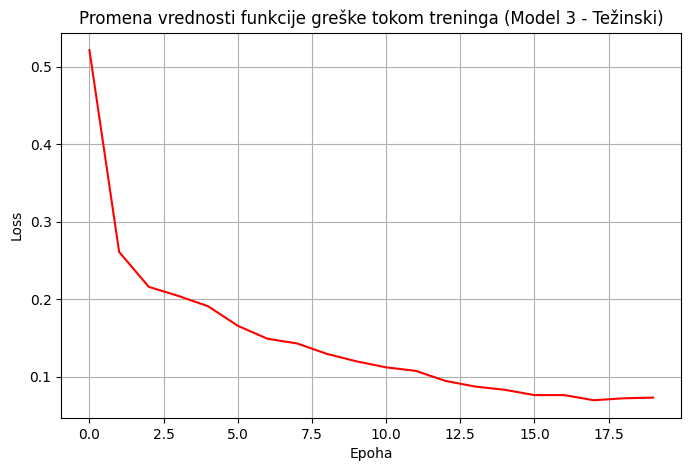

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(weighted_loss_history, color='red')
plt.xlabel("Epoha")
plt.ylabel("Loss")
plt.title("Promena vrednosti funkcije greške tokom treninga (Model 3 - Težinski)")
plt.grid(True)
plt.show()

<p align="justify">Vrednosti gubitka tokom epoha prikazane su na grafikonu iznad. Slično kao za prethodni model, gubitak je konstantno opadao od početnih 0.5 do 0.07 u 20. epohi, što ukazuje da je model uspešno naučio obrasce u podacima. </p>

## Evaluacija

In [ ]:
model_3_pytorch_weighted.eval()
y_pred_3 = []
y_true_3 = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        outputs = model_3_pytorch_weighted(batch_X)
        verovatnoce = torch.sigmoid(outputs)
        batch_pred = (verovatnoce >= 0.5).float()
        y_pred_3.extend(batch_pred.cpu().numpy().flatten())
        y_true_3.extend(batch_y.cpu().numpy().flatten())

### Matrica konfuzije

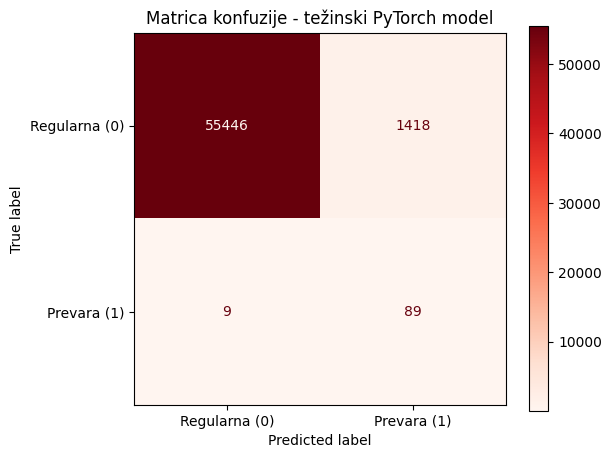

In [ ]:
cm_weighted = confusion_matrix(y_true_3, y_pred_3)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_weighted, display_labels=['Regularna (0)', 'Prevara (1)'])
disp.plot(cmap='Reds', ax=plt.gca(), values_format='g')
plt.title("Matrica konfuzije - težinski PyTorch model")
plt.grid(False)
plt.show()

<p align="justify">
Težinski PyTorch model uspešno je identifikovao 89 stvarnih prevara (<b>True Positive</b>) i tačno klasifikovao 55.446 regularne transakcije (<b>True Negative</b>). Možemo da zaključimo da je uvođenje težinske funkcije greške povećalo broj utvrđenih prevari. Ali isto tako, model je postao izuzetno osetljiv na klasu prevara. Iako u datoj matrici konfuzije uočavamo samo 9 propuštenih prevara (<b> False Negative</b>) povećao se broj lažnih uzbuna i to na 1418 (<b>False Positive</b>).
</p>

## Klasifikacioni izveštaj

In [ ]:
print("Klasifikacioni izveštaj za težinski Pytorch model: \n")
print(classification_report(y_true_3, y_pred_3, target_names=['Regularna (0)', 'Prevara (1)']))

Klasifikacioni izveštaj za težinski Pytorch model: 

               precision    recall  f1-score   support

Regularna (0)       1.00      0.98      0.99     56864
  Prevara (1)       0.06      0.91      0.11        98

     accuracy                           0.97     56962
    macro avg       0.53      0.94      0.55     56962
 weighted avg       1.00      0.97      0.99     56962



<p align="justify">
Uvođenjem parametra pos_weight u funkciju greške (Model 3), uspešno smo modifikovali ponašanje mreže u uslovima ekstremnog debalansa klasa:</p>

*   **Maksimizacija odziva (Recall)**

<p align="justify">
(Recall) za klasu prevara je zabeležio rekordan skok na 0.91. Sa biznis strane, ovo znači da model sada uspešno identifikuje čak 91% zabranjenih aktivnosti, što je ogroman napredak u odnosu na prethodne modele.</p>

*    **Kompromis sa preciznošću (Trade-off)**

<p align="justify">
Ekstremno visoka osetljivost modela dovela je do drastičnog pada preciznosti (Precision) na 0.06. Model je postao previše rigorozan, što dovodi do velikog broja lažno pozitivnih rezultata (lažnih uzbuna), gde se regularnim korisnicima blokiraju transakcije.</p>

<p align="justify">
Ovaj model je odličan primer pomeranja praga odlučivanja u korist bezbednosti. Međutim, niska preciznost i pad F1-score-a od samo 0.11 ukazuju na to da je model previše nestabilan za realnu primenu.</p>

# **Model 4: Regularizovani PyTorch MLP model**

## Pravljenje modela

<p align="justify">
Nakon uspešne implementacije težinske funkcije greške (Model 3), primetili smo značajan porast odziva (recall) na klasu prevara, ali i drastičan broj lažno pozitivnih ishoda – model je previše „verovao” svojim predikcijama i često regularne transakcije označavao kao sumnjive. Ovakvo ponašanje ukazuje na preprilagođavanje (<b>overfitting</b>): model je zapamtio šumove i specifičnosti trening podataka, umesto da nauči opšte obrasce koji se odnose na prevaru.</p>
<p align="justify">
Da bismo sprečili preprilagođavanje, uvodimo regularizaciju kroz tehniku Dropout. Dropout se primenjuje na aktivacije neurona tokom treninga – nasumično „isključuje” određeni procenat neurona (u našem slučaju 20%) sa verovatnoćom p=0.2. Time se sprečava da mreža postane previše zavisna od pojedinačnih neurona, što podstiče robusnije učenje i bolju generalizaciju na neviđenim podacima.</p>

In [ ]:
class RegularizedFraudMLP(nn.Module):
    def __init__(self):
        super(RegularizedFraudMLP, self).__init__()
        self.fc1 = nn.Linear(30, 64)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.2)

        self.fc2 = nn.Linear(64, 32)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.2)

        self.fc3 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.dropout1(self.relu1(self.fc1(x)))
        x = self.dropout2(self.relu2(self.fc2(x)))
        x = self.fc3(x)
        return x

set_seed(RAND_STATE)
model_4_pytorch_reg = RegularizedFraudMLP()
print(model_4_pytorch_reg)

RegularizedFraudMLP(
  (fc1): Linear(in_features=30, out_features=64, bias=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (dropout2): Dropout(p=0.2, inplace=False)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
)


## Trening modela

In [ ]:
criterion_reg = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
optimizer_reg = optim.Adam(model_4_pytorch_reg.parameters(), lr=0.001, weight_decay=1e-4)

reg_loss_history = []
EPOCHS = 20

for epoch in range(EPOCHS):
    model_4_pytorch_reg.train()
    tekuci_loss_za_epohu = 0.0
    broj_paketa = 0

    for batch_X, batch_y in train_loader:
        optimizer_reg.zero_grad()

        outputs = model_4_pytorch_reg(batch_X)
        loss = criterion_reg(outputs, batch_y)

        loss.backward()
        optimizer_reg.step()

        tekuci_loss_za_epohu += loss.item()
        broj_paketa += 1

    prosecan_loss_epohe = tekuci_loss_za_epohu / broj_paketa
    reg_loss_history.append(prosecan_loss_epohe)

    print(f"Epoha [{epoch+1}/{EPOCHS}] - Istorija Loss-a: {prosecan_loss_epohe:.5f}")

Epoha [1/20] - Istorija Loss-a: 0.58171
Epoha [2/20] - Istorija Loss-a: 0.29790
Epoha [3/20] - Istorija Loss-a: 0.25296
Epoha [4/20] - Istorija Loss-a: 0.23871
Epoha [5/20] - Istorija Loss-a: 0.23007
Epoha [6/20] - Istorija Loss-a: 0.20625
Epoha [7/20] - Istorija Loss-a: 0.19125
Epoha [8/20] - Istorija Loss-a: 0.18270
Epoha [9/20] - Istorija Loss-a: 0.18320
Epoha [10/20] - Istorija Loss-a: 0.17514
Epoha [11/20] - Istorija Loss-a: 0.16343
Epoha [12/20] - Istorija Loss-a: 0.16628
Epoha [13/20] - Istorija Loss-a: 0.15432
Epoha [14/20] - Istorija Loss-a: 0.13642
Epoha [15/20] - Istorija Loss-a: 0.14130
Epoha [16/20] - Istorija Loss-a: 0.15147
Epoha [17/20] - Istorija Loss-a: 0.13468
Epoha [18/20] - Istorija Loss-a: 0.12348
Epoha [19/20] - Istorija Loss-a: 0.12338
Epoha [20/20] - Istorija Loss-a: 0.12764


## Promena vrednosti funkcije greške tokom treninga

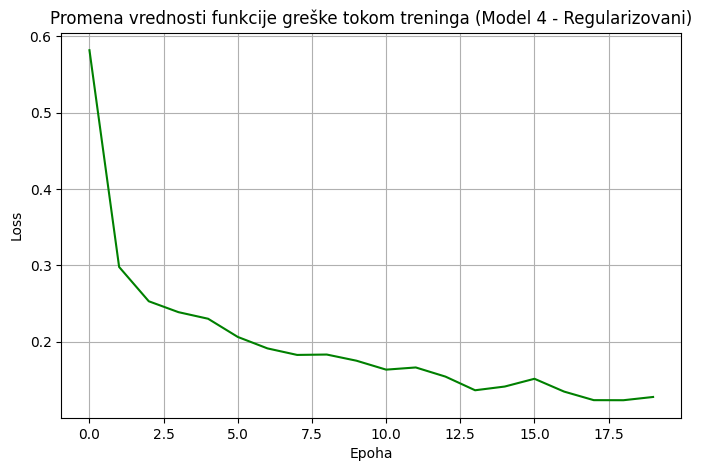

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(reg_loss_history, color='green')
plt.xlabel("Epoha")
plt.ylabel("Loss")
plt.title("Promena vrednosti funkcije greške tokom treninga (Model 4 - Regularizovani)")
plt.grid(True)
plt.show()

<p align="justify">Vrednosti gubitka tokom epoha za regularizovani Pytorch model prikazane su na grafikonu iznad. Gubitak je opadao od početnih približno 0.58 do oko 0.12 u 20. epohi, što ukazuje da je model uspešno naučio obrasce u podacima. Iako su na krivoj prisutne blage fluktuacije (poput manjih skokova oko 4. i 15. epohe), ovakvo ponašanje je uobičajeno i očekivano pri primeni tehnika regularizacije. Opšti trend je jasan opadajući i sugeriše stabilnu konvergenciju. Nema znakova preteranog prilagođavanja (overfitting) na samom trening skupu.</p>

## Evaluacija

In [ ]:
model_4_pytorch_reg.eval()
y_pred_4 = []
y_true_4 = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        outputs = model_4_pytorch_reg(batch_X)
        verovatnoce = torch.sigmoid(outputs)
        batch_pred = (verovatnoce >= 0.5).float()

        y_pred_4.extend(batch_pred.cpu().numpy().flatten())
        y_true_4.extend(batch_y.cpu().numpy().flatten())

### Matrica konfuzije

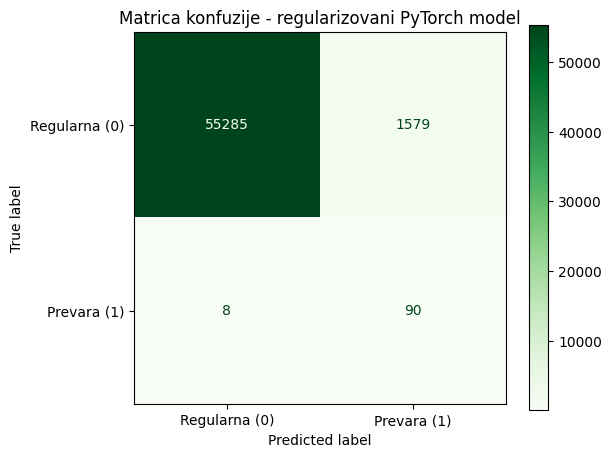

In [ ]:
cm_reg = confusion_matrix(y_true_4, y_pred_4)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_reg, display_labels=['Regularna (0)', 'Prevara (1)'])
disp.plot(cmap='Greens', ax=plt.gca(), values_format='g')
plt.title("Matrica konfuzije - regularizovani PyTorch model")
plt.grid(False)
plt.show()

<p align="justify">Na osnovu prikazane matrice konfuzije za regularizovani model, detaljnije se može sagledati uspešnost klasifikacije transakcija. Model je tačno identifikovao 55.285 regularnih transakcija (<b>True Negative</b>) i uspešno detektovao 90 stvarnih prevara (<b>True Positive</b>). S druge strane, model je 1.579 regularnih transakcija pogrešno klasifikovao kao prevare (<b>False Positive</b>), dok je propustio samo 8 stvarnih prevara (<b>False Negative</b>).

<p align="justify">
Ovakav raspored vrednosti ukazuje na to da je model izuzetno osetljiv na prevare (visoka vrednost odziva/recall-a), što je često i primarni cilj u ovakvim sistemima jer minimizuje rizik od nedetektovanih zloupotreba. Ipak, prisutan je veći broj lažnih uzbuna koje mogu zahtevati dodatne resurse za ručnu proveru.</p>

<p align="justify">Možemo da zaključimo da su vrednosti u matrici konfuzije ovog modela slični kao i za prethodni model, samo još rigorozniji.</b>

### Klasifikacioni izveštaj

In [ ]:
print("Klasifikacioni izveštaj za regularizovani Pytorch model: \n")
print(classification_report(y_true_4, y_pred_4, target_names=['Regularna (0)', 'Prevara (1)']))

Klasifikacioni izveštaj za regularizovani Pytorch model: 

               precision    recall  f1-score   support

Regularna (0)       1.00      0.97      0.99     56864
  Prevara (1)       0.05      0.92      0.10        98

     accuracy                           0.97     56962
    macro avg       0.53      0.95      0.54     56962
 weighted avg       1.00      0.97      0.98     56962



<p align="justify">Model ostvaruje izuzetno visok odziv (<b>Recall</b>) od 0.92, što znači da uspešno detektuje 92% svih stvarnih prevara. Sa druge strane, preciznost (<b>Precision</b>) za ovu klasu iznosi svega 0.05 (5%), što rezultira veoma niskim F1-skorom manjinske klase od 0.10. Ovakav odnos metrika je još jedan pokazatelj onoga što smo malo pre uvideli kroz matricu konfuzije - model generiše veliki broj lažnih uzbuna (False Positive) za svaku tačno detektovanu prevaru.</p>

<p align="justify">Analiza ukazuje na izražen kompromis (<i>trade-off</i>) između preciznosti i odziva, koji je čest kod sistema za detekciju anomalija. Model je očigledno kalibrisan tako da bude visoko osetljiv i maksimizuje identifikaciju zloupotreba (visok recall), svesno žrtvujući preciznost. Makro prosek F1-skora (<i>macro avg f1-score</i>) od 0.54 pruža znatno realniju i strožu ocenu opštih performansi modela na obe klase nego sama tačnost, jasno reflektujući slabost modela u preciznoj klasifikaciji pozitivne klase bez generisanja šuma.</p>

## Analiza osetljivosti

<p align="justify">Iako duboke neuronske mreže često postižu izuzetne performanse u klasifikacionim zadacima i detekciji anomalija, njihov glavni nedostatak leži u inherentnoj netransparentnosti. Zbog izrazito nelinearne arhitekture i velikog broja skrivenih parametara, ovakvi modeli se često posmatraju kao takozvane "crne kutije" (<i>black-box</i> modeli). Kako bi se prevazišao ovaj problem i razumela unutrašnja logika donošenja odluka regularizovanog modela, sprovodi se analiza osetljivosti (<i>Sensitivity Analysis</i>).</p>

<p align="justify">Primarni cilj ove analize je identifikacija i rangiranje ulaznih obeležja (varijabli) koja imaju najdominantniji uticaj na konačnu predikciju. U kontekstu predloženog rešenja, analiza osetljivosti se oslanja na izračunavanje gradijenata izlaza modela u odnosu na same ulazne podatke, koristeći mehanizam povratnog prostiranja greške (<i>backpropagation</i>). Prosečna apsolutna vrednost ovih gradijenata kvantifikuje osetljivost mreže – ona precizno pokazuje koliko bi se promenila izlazna verovatnoća (odluka o klasifikaciji transakcije) ukoliko bi se vrednost određenog obeležja minimalno izmenila. Što je vrednost gradijenta viša, to model pridaje veći značaj tom konkretnom atributu pri donošenju odluke.</p>

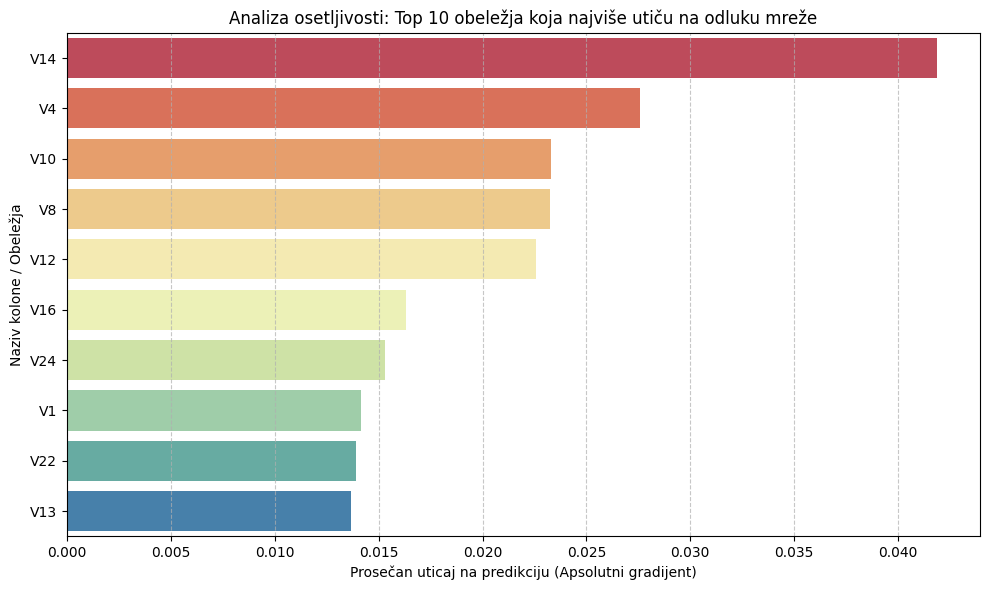

Obeležje  Osetljivost
     V14     0.041856
      V4     0.027561
     V10     0.023309
      V8     0.023227
     V12     0.022582
     V16     0.016339
     V24     0.015313
      V1     0.014143
     V22     0.013917
     V13     0.013648


In [ ]:
model_4_pytorch_reg = model_4_pytorch_reg.to('cpu')
model_4_pytorch_reg.eval()

X_sample = torch.tensor(X_test_scaled.values[:500], dtype=torch.float32, device='cpu').requires_grad_(True)

outputs = model_4_pytorch_reg(X_sample)
probabilities = torch.sigmoid(outputs)

probabilities.backward(torch.ones_like(probabilities))

sensitivity_scores = X_sample.grad.abs().mean(dim=0).cpu().numpy()

feature_names = X_test_scaled.columns
df_sensitivity = pd.DataFrame({
    'Obeležje': feature_names,
    'Osetljivost': sensitivity_scores
}).sort_values(by='Osetljivost', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Osetljivost', y='Obeležje', data=df_sensitivity.head(10), palette='Spectral')
plt.title("Analiza osetljivosti: Top 10 obeležja koja najviše utiču na odluku mreže")
plt.xlabel("Prosečan uticaj na predikciju (Apsolutni gradijent)")
plt.ylabel("Naziv kolone / Obeležja")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(df_sensitivity.head(10).to_string(index=False))

<p align="justify">
Možemo da istaknemo da je V14 glavni okidač modela. Visoka vrednost osetljivosti znači da čak i najmanja promena vrednosti ovog obeležja u ulaznom vektoru drastično menja izlaznu verovatnoću (odluku mreže da li je u pitanju prevara). Mreža se najviše oslanja na ovaj signal.</p>

<p align="justify">
S obzirom na to da su varijable dobijene PCA kompresijom, V14 i V4 predstavljaju ose sa najvećom varijansom koja razdvaja klae.</p>



## Uporedba klasifikacionih izveštaja svih modela

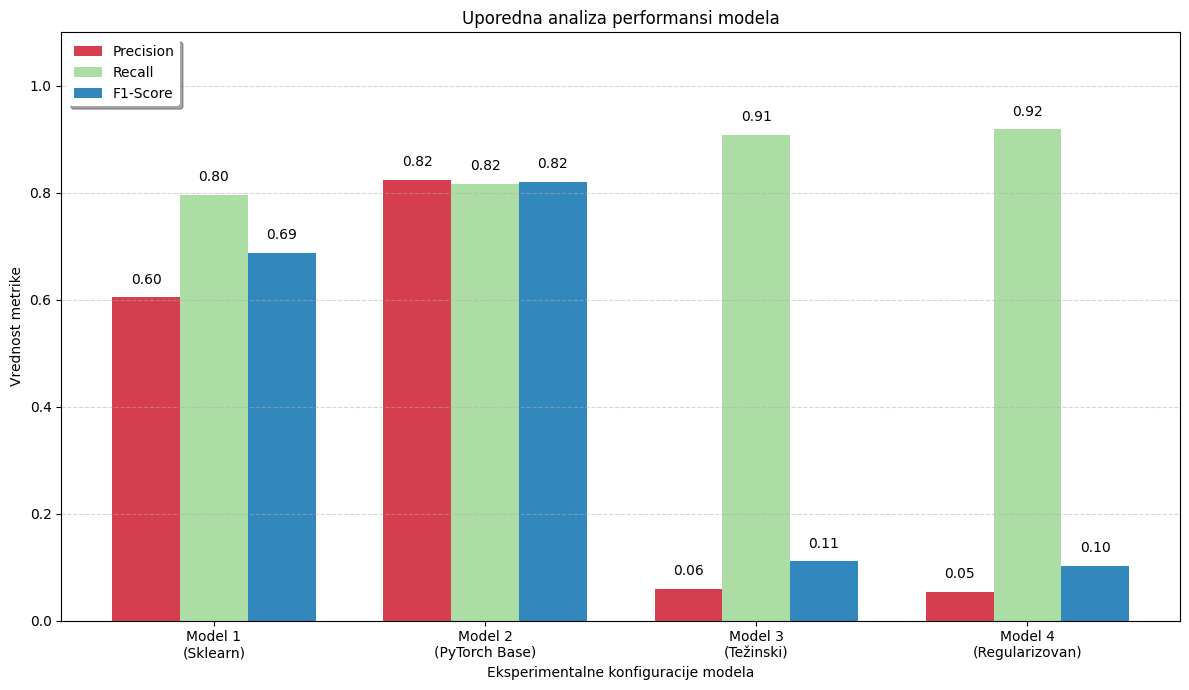

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Model 1 (Sklearn Baseline) - koristi y_test jer je rađen van DataLoader-a
p1, r1, f1_1 = precision_score(y_test, y_pred_1, zero_division=0), recall_score(y_test, y_pred_1), f1_score(y_test, y_pred_1)
# Model 2 (Osnovni PyTorch)
p2, r2, f1_2 = precision_score(y_true_2, y_pred_2, zero_division=0), recall_score(y_true_2, y_pred_2), f1_score(y_true_2, y_pred_2)
# Model 3 (Težinski PyTorch)
p3, r3, f1_3 = precision_score(y_true_3, y_pred_3, zero_division=0), recall_score(y_true_3, y_pred_3), f1_score(y_true_3, y_pred_3)
# Model 4 (Regularizovani PyTorch)
p4, r4, f1_4 = precision_score(y_true_4, y_pred_4, zero_division=0), recall_score(y_true_4, y_pred_4), f1_score(y_true_4, y_pred_4)

modeli = ['Model 1\n(Sklearn)', 'Model 2\n(PyTorch Base)', 'Model 3\n(Težinski)', 'Model 4\n(Regularizovan)']
precisions = [p1, p2, p3, p4]
recalls = [r1, r2, r3, r4]
f1_scores = [f1_1, f1_2, f1_3, f1_4]

x = np.arange(len(modeli))  # grupe na Ox
width = 0.25

plt.figure(figsize=(12, 7))
plt.bar(x - width, precisions, width, label='Precision', color='#d53e4f')
plt.bar(x, recalls, width, label='Recall', color='#abdda4')
plt.bar(x + width, f1_scores, width, label='F1-Score', color='#3288bd')

# Sređivanje estetike grafikona
plt.xlabel('Eksperimentalne konfiguracije modela')
plt.ylabel('Vrednost metrike')
plt.title('Uporedna analiza performansi modela')
plt.xticks(x, modeli, fontsize=10)
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none', shadow=True)

for i in range(len(modeli)):
    plt.text(i - width, precisions[i] + 0.02, f'{precisions[i]:.2f}', ha='center', va='bottom')
    plt.text(i, recalls[i] + 0.02, f'{recalls[i]:.2f}', ha='center', va='bottom')
    plt.text(i + width, f1_scores[i] + 0.02, f'{f1_scores[i]:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

<p align="justify">Na osnovu uporedne analize performansi prikazane na grafikonu, jasno se uočava dinamika kompromisa (<i>trade-off</i>) između metrika preciznosti i odziva (<i>Recall</i>) kroz različite eksperimentalne konfiguracije. Evolucija od osnovnih ka naprednijim arhitekturama otkriva dve potpuno različite strategije ponašanja mreže.</p>

<p align="justify"><b>Model 2 (PyTorch Base)</b> se izdvaja kao statistički najizbalansiranije i najsuperiornije opšte rešenje. Sa uniformnim vrednostima od 0.82 za Preciznost, Odziv i F1-skor, ova arhitektura predstavlja najstabilniji sistem. Model 2 uspešno pronalazi optimalnu granicu odlučivanja, istovremeno detektujući visok procenat anomalija, ali držeći broj lažnih uzbuna pod kontrolom.</p>

<p align="justify">S druge strane, uvođenjem specifičnih tehnika za rad sa nebalansiranim podacima kod <b>Modela 3 (Težinski)</b> i <b>Modela 4 (Regularizovan)</b>, mreža usvaja strategiju "nulte tolerancije" prema propuštenim klasama. Ovi modeli postaju izrazito ofanzivni, odbijajući da izgube ijedan sumnjiv slučaj, što rezultira maksimizacijom odziva (vrhunac od 0.92 kod Modela 4). Međutim, cena ove agresivne detekcije je kolaps preciznosti (pad na 0.05 kod Modela 4) i posledično drastično obaranje F1-skora, usled generisanja velikog broja lažno pozitivnih predikcija.</p>

<p align="justify">Konačno, izbor optimalnog modela direktno zavisi od poslovnih zahteva domena. Ukoliko je prioritet stabilan sistem koji minimizuje operativne troškove ručne provere (lažne uzbune), Model 2 je neosporan izbor. Ukoliko sistem zahteva maksimalnu rigoroznost gde je cena propuštene prevare neprihvatljivo visoka, Model 4 ostvaruje najbolji odziv, uprkos izraženom informacionom šumu.</p>